In [16]:
import numpy as np
import pandas as pd

from sklearn.linear_model import Ridge, ElasticNet
from sklearn.model_selection import ParameterGrid

import matplotlib.pyplot as plt

import sys, os, joblib
from datetime import datetime
from itertools import product
sys.path.append('../../')
import src.forecasting.simulations      as sim
import src.fda.kde.estimators           as kde
import src.fda.transformations.lqdt     as lqdt
import src.fda.dfpc              as dfpc
from pathlib import Path

In [19]:
EXECUTION_DATE : str = datetime.now().strftime('%Y%m%d')
EXECUTION_DATE = '20260604_03'

LOG_PATH        : str = f'../../logs/simulations/{EXECUTION_DATE}.log'
SIM_MAIN_PATH   : str = f'../../data/interim/simulation/{EXECUTION_DATE}/'
SIMS_PATH       : str = f'../../data/interim/simulation/{EXECUTION_DATE}/00_simulations/'
SIMS_LQD_PATH   : str = f'../../data/interim/simulation/{EXECUTION_DATE}/01_lqds/'
KDES_PATH       : str = f'../../data/interim/simulation/{EXECUTION_DATE}/02_kdes/'
KDES_LQDS_PATH  : str = f'../../data/interim/simulation/{EXECUTION_DATE}/03_kde_lqds/'
CV_FCS_PATH     : str = f'../../data/interim/simulation/{EXECUTION_DATE}/04_cv/'

Path(SIM_MAIN_PATH).mkdir(parents=True, exist_ok=True)
Path(SIMS_PATH).mkdir(parents=True, exist_ok=True)
Path(SIMS_LQD_PATH).mkdir(parents=True, exist_ok=True)
Path(KDES_PATH).mkdir(parents=True, exist_ok=True)
Path(KDES_LQDS_PATH).mkdir(parents=True, exist_ok=True)
Path(CV_FCS_PATH).mkdir(parents=True, exist_ok=True)
Path(LOG_PATH).parent.mkdir(parents=True, exist_ok=True)

In [ ]:
# Define scenarios
gas_params = {
    # "scenario_1": {
    #     "Description": "Location-driven ($m_t$)",
    #     "alpha": np.diag([0.08, 0.01, 0.01]),
    #     "beta": np.diag([0.90, 0.95, 0.95]),
    # },
    # "scenario_2": {
    #     "Description": "Scale-driven ($\sigma_t$)",
    #     "alpha": np.diag([0.01, 0.08, 0.01]),
    #     "beta": np.diag([0.95, 0.90, 0.95]),
    # },
    # "scenario_3": {
    #     "Description": "Shape-driven ($\eta_t$)",
    #      "alpha": np.diag([0.01, 0.01, 0.08]),
    #       "beta": np.diag([0.95, 0.95, 0.90])
    # },
    "scenario_4": {
        "Description": "Mixture",
        "alpha": np.diag([0.04, 0.06, 0.04]),
        "beta": np.diag([0.92, 0.95, 0.94]),
    }
}

distribution_params = {
    "nu": [3]
}

keys = ["scenario", "nu"]
values = [list(gas_params.keys()), distribution_params["nu"]]

param_grid = []

for scenario, nu in product(*values):
    gas_cfg = gas_params[scenario]

    param_grid.append({
        "scenario": "___nu=".join([scenario, str(nu)]),
        "nu": nu,
        "alpha": gas_cfg["alpha"],
        "beta": gas_cfg["beta"]    
})
    
# grid for densities
x = np.linspace(-40, 40, 5001)
# number of curves (densities)
T = 301
# number of simulations (f_{N_REP,1},...,f_{N_REP,T})
N_REPS = 10
# number of samples from each f_t density
N_SAMPLES = 288

total = len(param_grid) * N_REPS

sim_database = {}
total = len(param_grid) * N_REPS

for params in param_grid:
    scenario = params["scenario"]
    # Initialize scenario level
    sim_database[scenario] = {
        "params": params,
        "replications": {}
    }
    
    for n_rep in range(N_REPS):
        # 1. Setup Model and Simulate
        gm = sim.GasModel(alpha=params["alpha"], beta=params["beta"], nu=params["nu"])
        sim_results = gm.simulate(T=T, burn_in=300)
        
        # 2. Get Theoretical Densities
        sim_density = gm.conditional_densities(grid=x, theta_path=sim_results["theta"])
        dates = pd.date_range(end=pd.Timestamp.today().normalize(), periods=T, freq="D")
        sim_density.columns = dates
        
        # 3. Generate Samples Efficiently
        # Collect arrays first, then create DataFrame once
        samples_list = []
        for i in range(len(sim_results["theta"])):
            # Draw n samples for the theta at time i
            sample = gm.rvs(n=N_SAMPLES, theta=sim_results["theta"][i])
            samples_list.append(sample)
        
        # Create DataFrame: each column is a time step, each row a sample
        df_samples = pd.DataFrame(np.array(samples_list).T, columns=dates)
        
        # 4. Store in Database
        sim_database[scenario]["replications"][n_rep] = {
            "theta": sim_results["theta"],
            "densities": sim_density,
            "samples": df_samples
        }

returns_df = sim_database['scenario_4___nu=3']['replications'][0]['samples']
# bandwidths
kde_bw_params = {"method": "rot", "kernel": "gaussian", "sigma_robust":False}

df_h = kde.df_bandwidth_selector(returns_df, **kde_bw_params)    
kde_params = {k: v for k, v in kde_bw_params.items() if k in ['kernel', 'df']}

# kdes
df_grids, df_densities = kde.df_to_kde(
    X=returns_df, 
    h=df_h, 
    normalize_densities=False,
    **kde_params
)

Indexed 1575 KDE files


In [22]:
KdFPC_kwargs = {
    "p": 5,
    "dimension": 3
}

In [24]:
# Define scenarios
gas_params = {
    # "scenario_1": {
    #     "Description": "Location-driven ($m_t$)",
    #     "alpha": np.diag([0.08, 0.01, 0.01]),
    #     "beta": np.diag([0.90, 0.95, 0.95]),
    # },
    # "scenario_2": {
    #     "Description": "Scale-driven ($\sigma_t$)",
    #     "alpha": np.diag([0.01, 0.08, 0.01]),
    #     "beta": np.diag([0.95, 0.90, 0.95]),
    # },
    # "scenario_3": {
    #     "Description": "Shape-driven ($\eta_t$)",
    #      "alpha": np.diag([0.01, 0.01, 0.08]),
    #       "beta": np.diag([0.95, 0.95, 0.90])
    # },
    "scenario_4": {
        "Description": "Mixture",
        "alpha": np.diag([0.04, 0.06, 0.04]),
        "beta": np.diag([0.92, 0.95, 0.94]),
    }
}

distribution_params = {
    "nu": [3]
}

keys = ["scenario", "nu"]
values = [list(gas_params.keys()), distribution_params["nu"]]

param_grid = []

for scenario, nu in product(*values):
    gas_cfg = gas_params[scenario]

    param_grid.append({
        "scenario": "___nu=".join([scenario, str(nu)]),
        "nu": nu,
        "alpha": gas_cfg["alpha"],
        "beta": gas_cfg["beta"]    
})
    
# grid for densities
x = np.linspace(-40, 40, 5001)
# number of curves (densities)
T = 301
# number of simulations (f_{N_REP,1},...,f_{N_REP,T})
N_REPS = 10
# number of samples from each f_t density
N_SAMPLES = 288

total = len(param_grid) * N_REPS

sim_database = {}
total = len(param_grid) * N_REPS

for params in param_grid:
    scenario = params["scenario"]
    # Initialize scenario level
    sim_database[scenario] = {
        "params": params,
        "replications": {}
    }
    
    for n_rep in range(N_REPS):
        # 1. Setup Model and Simulate
        gm = sim.GasModel(alpha=params["alpha"], beta=params["beta"], nu=params["nu"])
        sim_results = gm.simulate(T=T, burn_in=300)
        
        # 2. Get Theoretical Densities
        sim_density = gm.conditional_densities(grid=x, theta_path=sim_results["theta"])
        dates = pd.date_range(end=pd.Timestamp.today().normalize(), periods=T, freq="D")
        sim_density.columns = dates
        
        # 3. Generate Samples Efficiently
        # Collect arrays first, then create DataFrame once
        samples_list = []
        for i in range(len(sim_results["theta"])):
            # Draw n samples for the theta at time i
            sample = gm.rvs(n=N_SAMPLES, theta=sim_results["theta"][i])
            samples_list.append(sample)
        
        # Create DataFrame: each column is a time step, each row a sample
        df_samples = pd.DataFrame(np.array(samples_list).T, columns=dates)
        
        # 4. Store in Database
        sim_database[scenario]["replications"][n_rep] = {
            "theta": sim_results["theta"],
            "densities": sim_density,
            "samples": df_samples
        }

returns_df = sim_database['scenario_4___nu=3']['replications'][0]['samples']
# bandwidths
kde_bw_params = {"method": "rot", "kernel": "gaussian", "sigma_robust":False}

df_h = kde.df_bandwidth_selector(returns_df, **kde_bw_params)    
kde_params = {k: v for k, v in kde_bw_params.items() if k in ['kernel', 'df']}

# kdes
df_grids, df_densities = kde.df_to_kde(
    X=returns_df, 
    h=df_h, 
    normalize_densities=False,
    **kde_params
)

In [25]:
mlqdt = lqdt.mLQDT()
model_lqd = mlqdt.transform(
    densities=df_densities,
    densities_supports=df_grids, 
    verbose=False
    )
# model_lqd.densities_to_lqdensities(verbose=False)

# 2. L2 Expansion (K_dFPC)
Y_t  = model_lqd.lqd.copy()
Y_t.index = model_lqd.lqd_support

/opt/anaconda3/envs/densities4risk/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:501: RuntimeWarning: overflow encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/opt/anaconda3/envs/densities4risk/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:504: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


In [47]:
KdFPC_kwargs = {
    "p": 5,
    "dimension": 3
}

lqd_values  = Y_t.values
lqd_support = Y_t.index.values

KdFPC_kwargs.update({
    "u": lqd_support,
    "du": model_lqd.du
})

model_kdfpc = dfpc.K_dFPC(lqd_values)
model_kdfpc.fit(**KdFPC_kwargs)

Y_t_fitted_d1 = pd.DataFrame(model_kdfpc.fitted_values, columns=Y_t.columns, index=Y_t.index)

In [48]:
KdFPC_kwargs = {
    "p": 5,
    "dimension": 10
}

lqd_values  = Y_t.values
lqd_support = Y_t.index.values

KdFPC_kwargs.update({
    "u": lqd_support,
    "du": model_lqd.du
})

model_kdfpc = dfpc.K_dFPC(lqd_values)
model_kdfpc.fit(**KdFPC_kwargs)

Y_t_fitted_d2 = pd.DataFrame(model_kdfpc.fitted_values, columns=Y_t.columns, index=Y_t.index)

In [65]:
def get_residual_plot(actual_df, fitted_df):
    """
    Calculates residuals and returns a plot showing all daily residual curves
    along with the average residual curve.
    
    Parameters:
    actual_df (pd.DataFrame): The original dataframe (Y_t)
    fitted_df (pd.DataFrame): The dataframe with fitted values
    
    Returns:
    matplotlib.figure.Figure: The generated plot figure
    """
    # 1. Calculate the residuals (Actual - Predicted)
    residuals = actual_df - fitted_df
    
    # 2. Calculate the average residual curve
    # axis=1 averages across the columns (dates) for each specific row index
    avg_residual = residuals.mean(axis=1)
        
    # 3. Initialize the plot
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # 4. Plot all individual daily residual curves
    # Passing the 2D values array plots each column as a separate line.
    # We use alpha=0.05 to make them highly transparent so they don't obscure the average.
    ax.plot(residuals.index, residuals.values, color='steelblue', alpha=0.05)
    
    # 5. Plot the Average Residual Curve on top
    ax.plot(avg_residual.index, avg_residual.values, color='red', linewidth=2.5, label='Average Residual Curve')
    
    # 6. Add a baseline at zero for reference
    ax.axhline(0, color='black', linestyle='--', linewidth=1.5, label='Zero Error Baseline')
    
    # 7. Formatting and labels
    ax.set_title('Residuals Between Actual and Fitted Curves', fontsize=14, fontweight='bold')
    ax.set_xlabel('Index (t)', fontsize=12)
    ax.set_ylabel('Residual Error (Actual - Fitted)', fontsize=12)
    
    # Clean up the legend (avoiding 300+ labels from the individual curves)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles, labels=labels, loc='best')
    
    plt.tight_layout()

    plt.ylim([-5,5])
    
    return fig

/var/folders/t3/pppk4b013151kb4wpjbj3hvh0000gn/T/ipykernel_22178/719354260.py:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  get_residual_plot(Y_t, Y_t_fitted_d1).show()


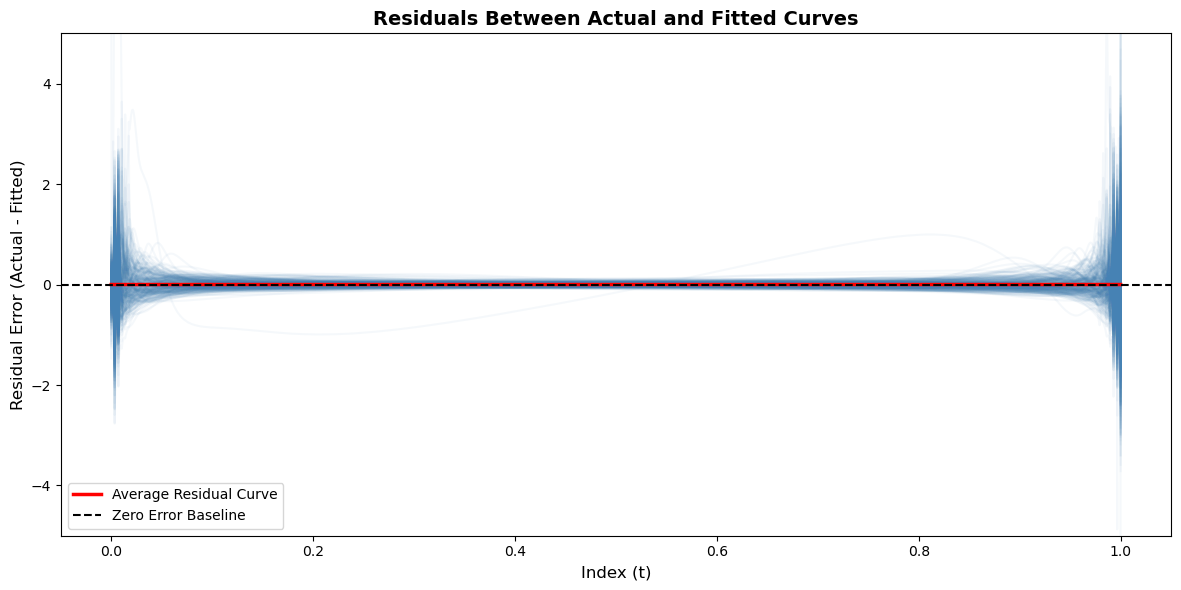

In [66]:
get_residual_plot(Y_t, Y_t_fitted_d1).show()